In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


# Exploratory Data Analysis (EDA) on Heart Disease Dataset

## 1. Introduction
This notebook performs Exploratory Data Analysis (EDA) on the Heart Disease dataset. The goal is to understand the structure of the data, identify trends and anomalies, test assumptions, and detect data quality issues.

## 2. Questions Before Analysis

Before analyzing the dataset, the following questions were considered:

1. What is the average age of patients in the dataset?
2. Are male patients more likely to have heart disease than female patients?
3. Is cholesterol related to heart disease?
4. Does blood pressure have any relationship with heart disease?
5. Are there any unusual or extreme values in the dataset?
6. Which variables appear to be most strongly related to the target variable?

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Dataset Sample
The first 5 rows of the dataset are shown above. This provides a quick overview of the patient records, including features like age, sex, chest pain type, blood pressure, cholesterol, and the target variable for heart disease.

In [4]:
df.shape

(1025, 14)

### Dataset Shape
The dataset contains 1025 rows and 14 columns. Each row represents a patient, and each column represents a clinical or demographic variable related to heart disease.

In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

### Column Names
The dataset contains the following features: age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, max heart rate, exercise-induced angina, oldpeak, slope, number of vessels, thal, and the target variable indicating presence of heart disease.

In [6]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

### Data Types of Columns
The output shows the type of data stored in each column. Most columns are integers (`int64`), such as age, sex, chest pain type (`cp`), and cholesterol (`chol`).  

Some columns may have floating-point values (`float64`), like `oldpeak`.  

Numeric columns represent either:
- **Continuous measurements** (e.g., age, cholesterol, resting blood pressure)
- **Categorical information encoded as numbers** (e.g., sex: 0 = female, 1 = male; chest pain type: 1–4)  

Understanding data types is crucial for choosing the right analysis, visualization, and statistical methods.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Dataset Information Summary
The `.info()` output provides a concise overview of the dataset:

- The dataset contains **1025 rows** and **14 columns**.
- Each column lists the **number of non-null values** and its **data type**.
- Most columns are integers (`int64`) representing either **continuous measurements** (e.g., age, blood pressure, cholesterol) or **categorical variables encoded as numbers** (e.g., sex, chest pain type).
- The `oldpeak` column is a floating-point (`float64`) variable.
- There are **no missing values** in the dataset, as all columns have 1025 non-null entries.

This summary confirms the dataset is complete and ready for analysis.

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Statistical Summary
The `.describe()` output shows basic statistics for numeric columns:

- **count:** 1025 (no missing values)  
- **mean / std:** average and spread of values  
- **min / max / quartiles:** distribution and extremes  

Useful to spot trends, detect anomalies, and guide further analysis.

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Missing Values Check
All columns have 1025 non-null entries. There are no missing values, so the dataset is complete.

In [10]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

### Heart Disease Distribution
Shows how many patients have heart disease (1) and how many do not (0).

In [11]:
df['sex'].value_counts()

sex
1    713
0    312
Name: count, dtype: int64

### Gender Distribution
Shows the number of male (1) and female (0) patients in the dataset.

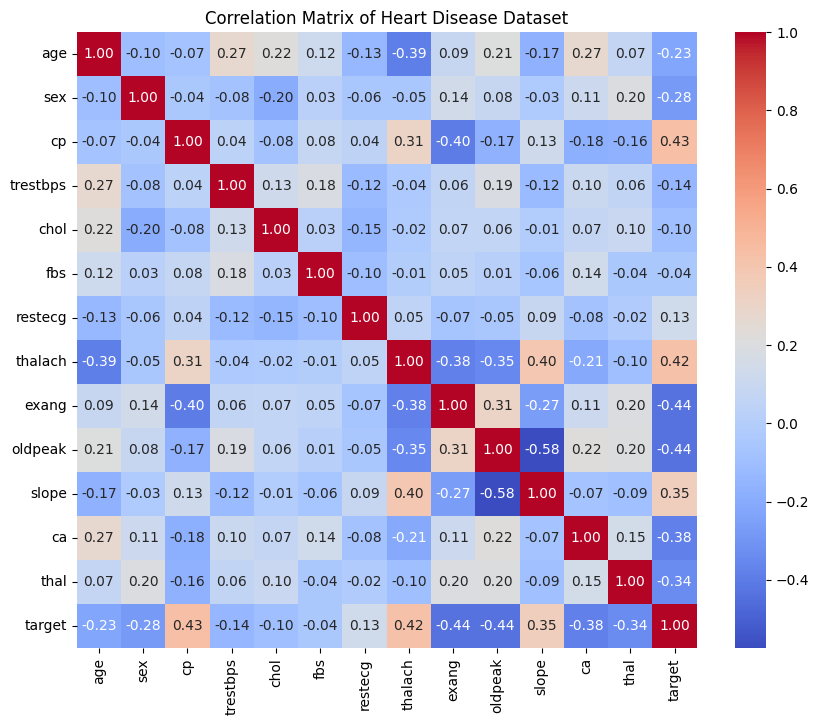

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Heart Disease Dataset")
plt.show()

### Correlation Matrix
The heatmap shows how features are correlated with each other and with the target variable.  
High correlation values can reveal patterns, e.g., certain clinical measurements may strongly relate to heart disease.

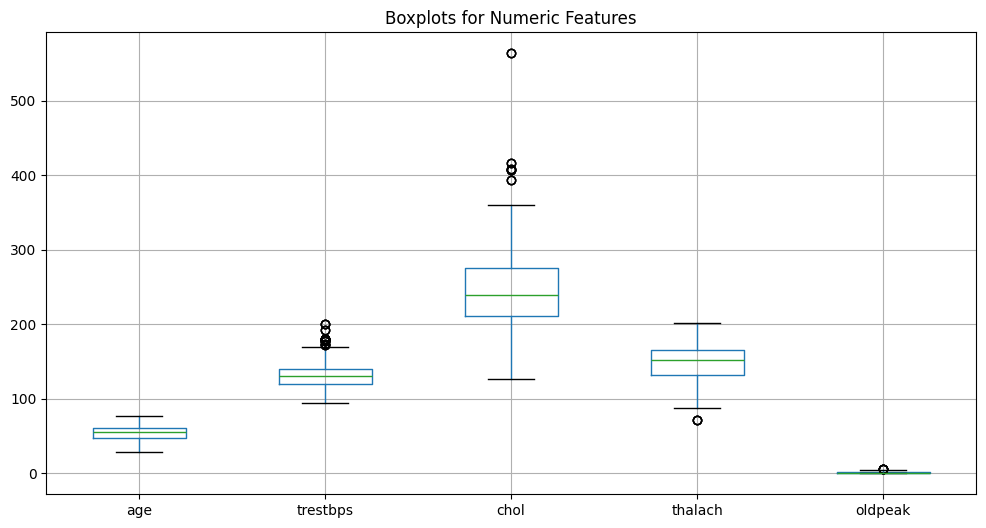

In [14]:
numeric_cols = ['age','trestbps','chol','thalach','oldpeak']
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.title("Boxplots for Numeric Features")
plt.show()

### Outlier Detection
Boxplots help detect extreme values in numeric features. Outliers can affect analysis and models, so they may need attention.

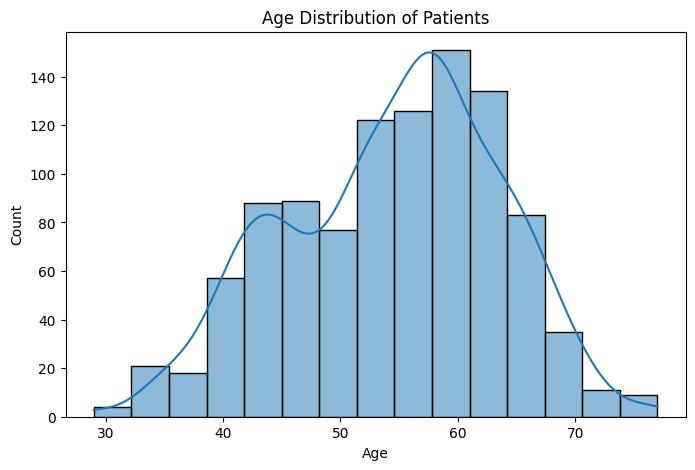

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=15, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Age Distribution
Histogram shows the distribution of patient ages. Most patients are between 50-60 years, helping understand the dataset's demographics.

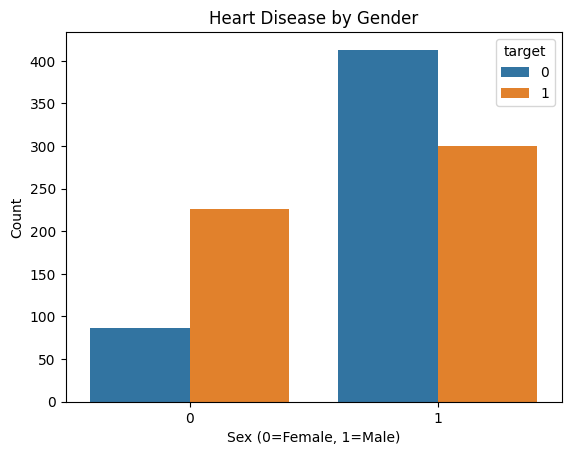

In [16]:
sns.countplot(x='sex', hue='target', data=df)
plt.title("Heart Disease by Gender")
plt.xlabel("Sex (0=Female, 1=Male)")
plt.ylabel("Count")
plt.show()

### Heart Disease by Gender
Countplot shows prevalence of heart disease among males and females. This helps explore patterns or trends in gender.

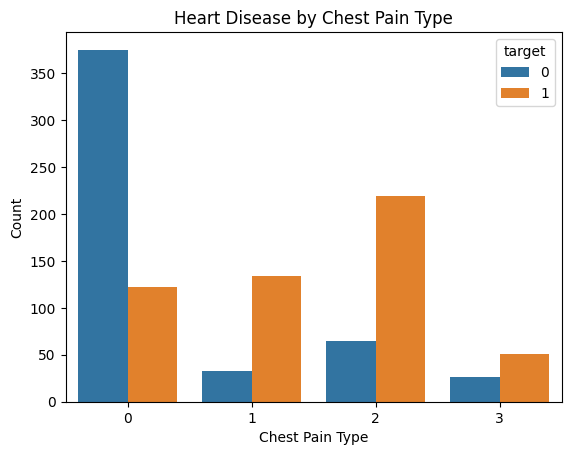

In [17]:
sns.countplot(x='cp', hue='target', data=df)
plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

### Heart Disease by Chest Pain Type
This plot shows how heart disease occurrence varies with different types of chest pain, revealing important trends in patient symptoms.

### EDA Insights & Conclusion

After performing exploratory data analysis on the Heart Disease dataset, we observed the following:

1. **Dataset Overview**  
   - 1025 entries and 14 columns, with no missing values.  
   - Majority of features are numeric (integers) and one float (`oldpeak`).  

2. **Target Distribution**  
   - Approximately half of the patients have heart disease (`target = 1`).  

3. **Demographics & Patterns**  
   - Most patients are between 50-60 years old.  
   - Males have a slightly higher prevalence of heart disease than females.  
   - Certain chest pain types are more associated with heart disease.  

4. **Outliers & Anomalies**  
   - Boxplots revealed some extreme values in cholesterol, blood pressure, and oldpeak, which may require attention in modeling.  

5. **Feature Relationships**  
   - Correlation analysis shows features like `thalach` (max heart rate) and `oldpeak` (ST depression) are correlated with the target.  

**Conclusion:**  
The dataset is clean, complete, and ready for further analysis or predictive modeling. Patterns observed in gender, age, and chest pain type can guide feature selection and hypothesis testing in future steps.